# 04 Visualizations

This notebook develops polished visualizations for both the underlying fraud dataset and the model results.

While the earlier EDA notebook focused on initial exploration, the purpose of this notebook is to create clearer, more intentional visuals that better support interpretation, comparison, and presentation.

The main goals of this notebook are to:

- refine and expand visual exploration of the original fraud dataset
- highlight important class imbalance and transaction patterns
- visualize Logistic Regression tuning and threshold tradeoffs
- visualize Random Forest tuning and depth performance
- compare final model performance across selected metrics
- create presentation-ready charts that communicate both the data story and the modeling results

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 
import seaborn as sns
import plotly.express as px
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import roc_curve, auc


from pyspark.sql import functions as F

from project.config import load_config
from project.schemas import TRANSACTION_SCHEMA
from project.spark_session import create_spark
from project.transform import prepare_transactions

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["legend.fontsize"] = 12

In [2]:
repo_root = Path.cwd().parent
cfg = load_config(repo_root / "configs" / "local.yaml")
data_file = repo_root / "data" / "raw" / "credit_card_transactions.csv"

spark = create_spark(cfg)
spark.sparkContext.setLogLevel("WARN")

models_path = repo_root / "data" / "models"

print("Spark session created.")
print(f"Models path: {models_path}")

Spark session created.
Models path: /home/jovyan/work/data/models


## Load Credit Card Transaction Dataset

The following dataset is loaded to create cleaner and more in depth visualizations of the data.

In [3]:
cc_df = (spark.read
         .option("header", True)
         .option("timestampFormat", "yyyy-MM-dd HH:mm:ss")
         .option("dateFormat", "yyyy-MM-dd")
         .schema(TRANSACTION_SCHEMA)
         .csv(str(data_file))
)

cc_df = prepare_transactions(cc_df)

## Load Saved Model Outputs

The following datasets were saved from the modeling notebook and are loaded here for visualization.

These outputs include parameter tuning results, threshold tuning results, scored predictions, and final model comparison data.

In [4]:
lr_param_tuning = spark.read.parquet(str(models_path / "lr_param_tuning"))
lr_threshold_tuning = spark.read.parquet(str(models_path / "lr_threshold_tuning"))
lr_scored_predictions = spark.read.parquet(str(models_path / "lr_scored_predictions"))
rf_param_tuning = spark.read.parquet(str(models_path / "rf_param_tuning"))
rf_depth_tuning = spark.read.parquet(str(models_path / "rf_depth_tuning"))

In [5]:
lr_param_pd = lr_param_tuning.toPandas()
lr_threshold_pd = lr_threshold_tuning.toPandas()
rf_param_pd = rf_param_tuning.toPandas()

# prediction-level data can be larger, so keep this separate
lr_scored_pd = lr_scored_predictions.toPandas()

## Prepare Visualization Data

Before plotting, some saved outputs need minor cleanup so values such as thresholds and model depth can be extracted from the model labels and used directly in charts.

In [6]:
lr_threshold_pd["threshold"] = (
    lr_threshold_pd["model"]
    .str.extract(r"([0-9]*\.?[0-9]+)")
    .astype(float)
)


# optional sort for cleaner charts
lr_threshold_pd = lr_threshold_pd.sort_values("threshold", ascending=False)

In [7]:
eda_pd = (
    cc_df
    .select(
        "is_fraud",
        "amt",
        "amt_log",
        "category",
        "gender",
        "age",
        "state",
        "city_pop",
        "event_hour",
        "event_month",
        "event_dayofweek"
    )
    .sample(False, 0.15, seed=5420)
    .toPandas()
)

## Class Imbalance

The dataset is highly imbalanced, with fraudulent transactions representing only a small fraction of the total data. This imbalance is a key challenge for modeling, as traditional metrics like accuracy can be misleading.

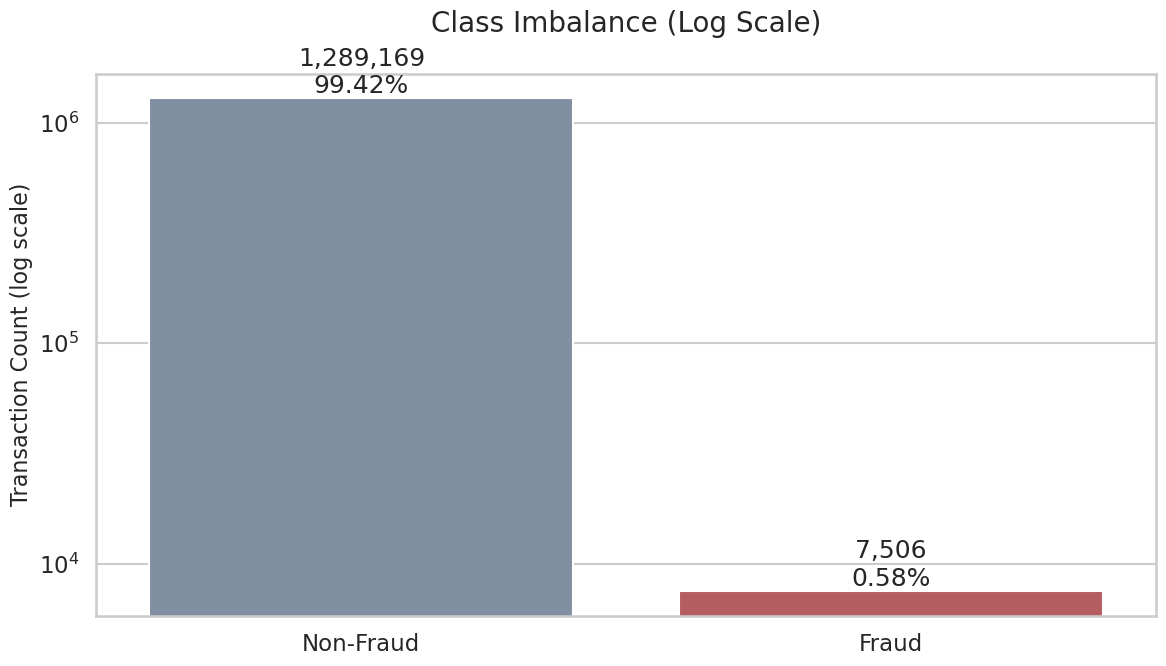

In [8]:
class_counts_pd = (
    cc_df.groupBy("is_fraud")
    .count()
    .toPandas()
    .sort_values("is_fraud")
    .reset_index(drop=True)
)

labels = ["Non-Fraud", "Fraud"]
counts = class_counts_pd["count"]
percents = counts / counts.sum() * 100

plt.figure()

sns.barplot(
    x=labels,
    y=counts,
    hue=labels,
    palette=["#7a8fa6", "#c44e52"],
    legend=False
)

plt.yscale("log")


for i, (c, p) in enumerate(zip(counts, percents)):
    plt.text(i, c, f"{c:,}\n{p:.2f}%", ha="center", va="bottom")

plt.title("Class Imbalance (Log Scale)", pad=30)
plt.ylabel("Transaction Count (log scale)")
plt.xlabel("")

plt.tight_layout()
plt.show()

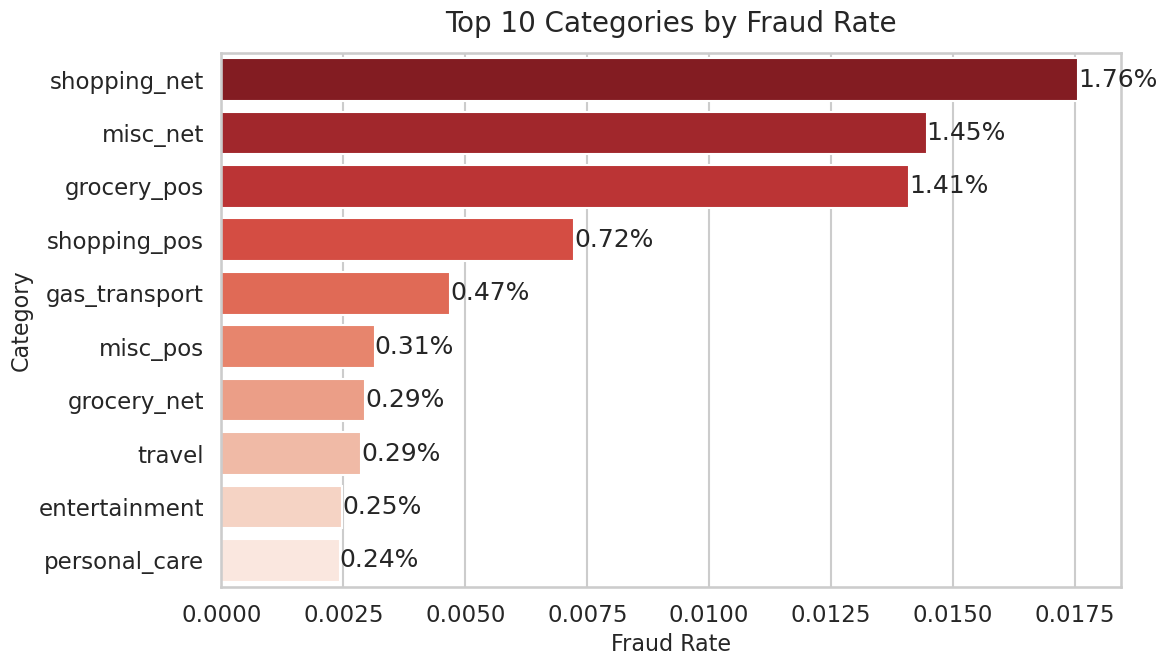

In [9]:
category_summary_pd = (
    cc_df.groupBy("category")
    .agg(
        F.count("*").alias("txn_count"),
        F.sum("is_fraud").alias("fraud_count")
    )
    .withColumn("fraud_rate", F.col("fraud_count") / F.col("txn_count"))
    .orderBy(F.desc("fraud_rate"))
    .toPandas()
)

top_n = 10

top_categories = category_summary_pd.head(top_n)

plt.figure()

sns.barplot(
    data=top_categories,
    x="fraud_rate",
    y="category",
    hue="category",
    palette=sns.color_palette("Reds_r", n_colors=len(top_categories)),
    legend=False
)

plt.title(f"Top {top_n} Categories by Fraud Rate", pad=15)
plt.xlabel("Fraud Rate")
plt.ylabel("Category")

for i, row in top_categories.reset_index(drop=True).iterrows():
    plt.text(
        row["fraud_rate"],
        i,
        f"{row['fraud_rate']*100:.2f}%",
        va="center",
        ha="left"
    )

plt.tight_layout()
plt.show()

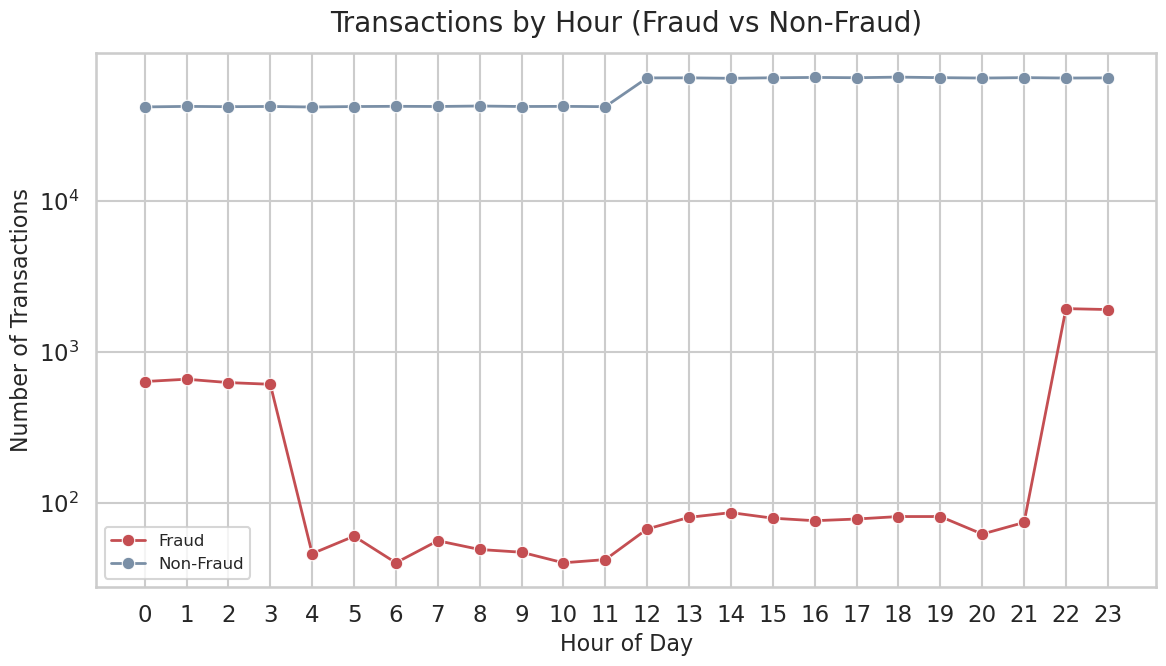

In [10]:
hour_summary_pd = (
    cc_df.groupBy("event_hour")
    .agg(
        F.count("*").alias("txn_count"),
        F.sum("is_fraud").alias("fraud_count")
    )
    .withColumn("nonfraud_count", F.col("txn_count") - F.col("fraud_count"))
    .orderBy("event_hour")
    .toPandas()
)

fig, ax = plt.subplots()

sns.lineplot(
    data=hour_summary_pd,
    x="event_hour",
    y="fraud_count",
    marker="o",
    linewidth=2,
    color="#c44e52",
    label="Fraud",
    ax=ax
)

sns.lineplot(
    data=hour_summary_pd,
    x="event_hour",
    y="nonfraud_count",
    marker="o",
    linewidth=2,
    color="#7a8fa6",
    label="Non-Fraud",
    ax=ax
)

ax.set_title("Transactions by Hour (Fraud vs Non-Fraud)", pad=15)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Transactions")
ax.set_xticks(range(0, 24))
ax.set_yscale("log")
ax.legend()

plt.tight_layout()
plt.show()

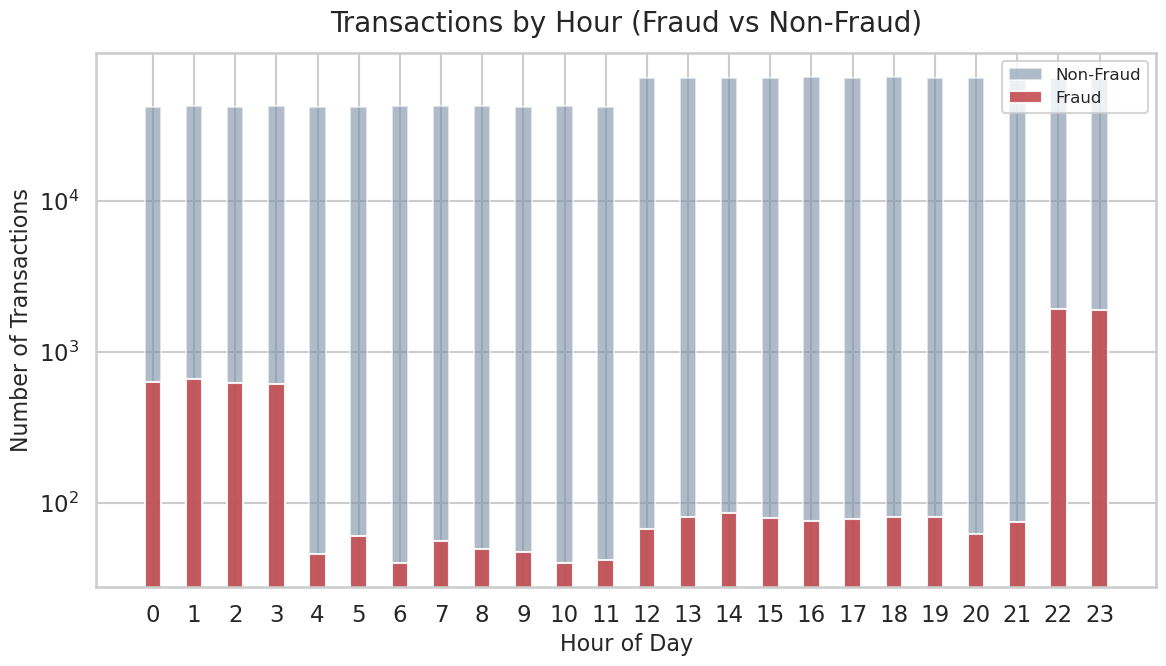

In [11]:
hour_summary_pd = (
    cc_df.groupBy("event_hour")
    .agg(
        F.count("*").alias("txn_count"),
        F.sum("is_fraud").alias("fraud_count")
    )
    .withColumn("nonfraud_count", F.col("txn_count") - F.col("fraud_count"))
    .orderBy("event_hour")
    .toPandas()
)

fig, ax = plt.subplots()

x = hour_summary_pd["event_hour"]
width = 0.4

# Non-Fraud (background)
ax.bar(
    x,
    hour_summary_pd["nonfraud_count"],
    width=width,
    color="#7a8fa6",
    alpha=0.6,
    label="Non-Fraud"
)

# Fraud (overlay)
ax.bar(
    x,
    hour_summary_pd["fraud_count"],
    width=width,
    color="#c44e52",
    alpha=0.9,
    label="Fraud"
)

ax.set_title("Transactions by Hour (Fraud vs Non-Fraud)", pad=15)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Transactions")
ax.set_xticks(range(0, 24))
ax.set_yscale("log")
ax.legend()

plt.tight_layout()
plt.show()

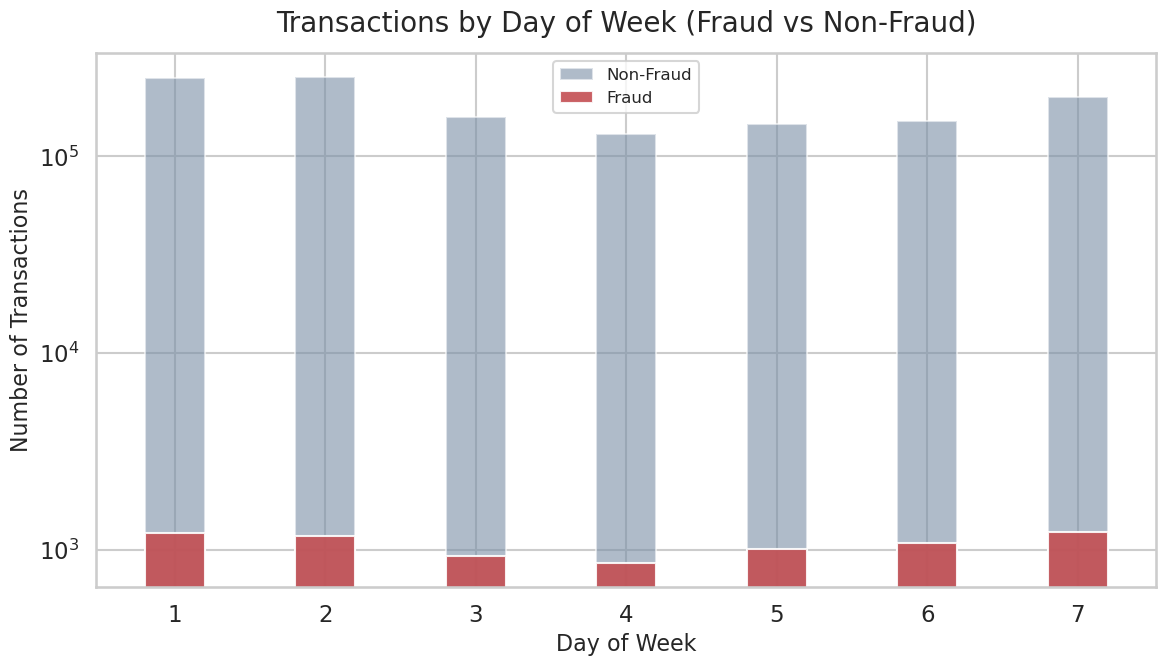

In [12]:
dow_summary_pd = (
    cc_df.groupBy("event_dayofweek")
    .agg(
        F.count("*").alias("txn_count"),
        F.sum("is_fraud").alias("fraud_count")
    )
    .withColumn("nonfraud_count", F.col("txn_count") - F.col("fraud_count"))
    .withColumn("fraud_rate", F.col("fraud_count") / F.col("txn_count"))
    .orderBy("event_dayofweek")
    .toPandas()
)

fig, ax = plt.subplots()

x = dow_summary_pd["event_dayofweek"]
width = 0.4

# Non-Fraud (background)
ax.bar(
    x,
    dow_summary_pd["nonfraud_count"],
    width=width,
    color="#7a8fa6",
    alpha=0.6,
    label="Non-Fraud"
)

# Fraud (overlay)
ax.bar(
    x,
    dow_summary_pd["fraud_count"],
    width=width,
    color="#c44e52",
    alpha=0.9,
    label="Fraud"
)

ax.set_title("Transactions by Day of Week (Fraud vs Non-Fraud)", pad=15)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Number of Transactions")
ax.set_xticks(range(1, 8))
ax.set_yscale("log")
ax.legend()

plt.tight_layout()
plt.show()

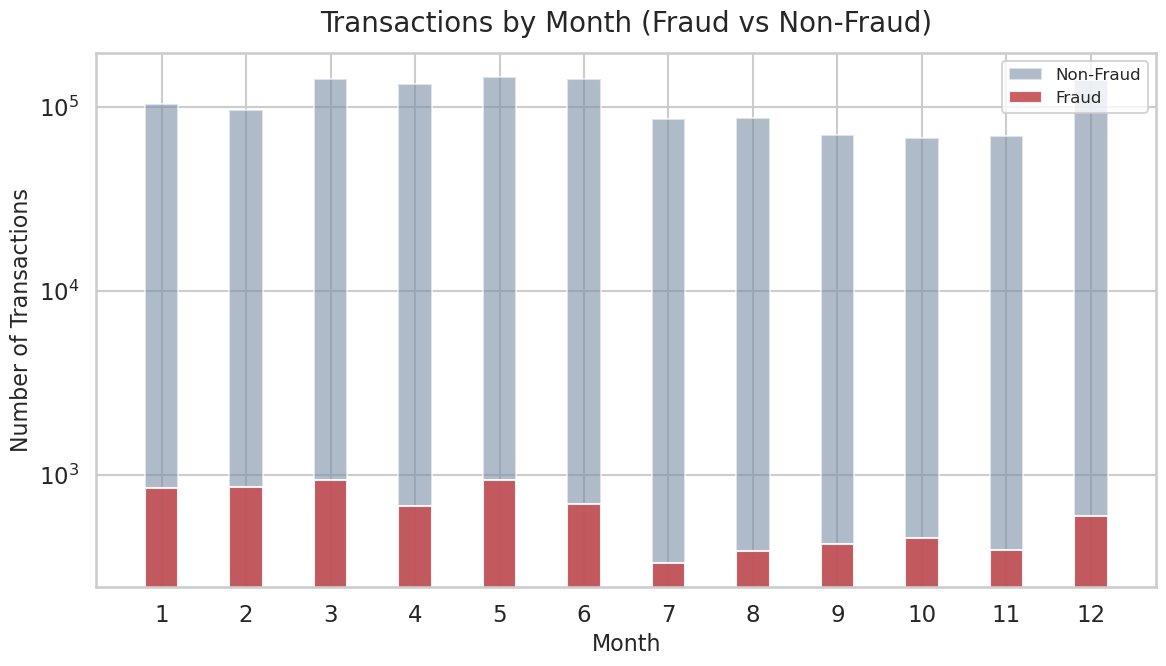

In [13]:
month_pd = ( 
    cc_df.groupBy("is_fraud", "event_month")
        .count()
        .orderBy("is_fraud", "event_month")
        .toPandas()
   )

fig, ax = plt.subplots()

x = month_pd[month_pd["is_fraud"] == 0]["event_month"]
width = 0.4

# Non-Fraud (background)
ax.bar(
    x,
    month_pd[month_pd["is_fraud"] == 0]["count"],
    width=width,
    color="#7a8fa6",
    alpha=0.6,
    label="Non-Fraud"
)

# Fraud (overlay)
ax.bar(
    x,
    month_pd[month_pd["is_fraud"] == 1]["count"],
    width=width,
    color="#c44e52",
    alpha=0.9,
    label="Fraud"
)

ax.set_title("Transactions by Month (Fraud vs Non-Fraud)", pad=15)
ax.set_xlabel("Month")
ax.set_ylabel("Number of Transactions")
ax.set_xticks(range(1, 13))
ax.set_yscale("log")
ax.legend()

plt.tight_layout()
plt.show()

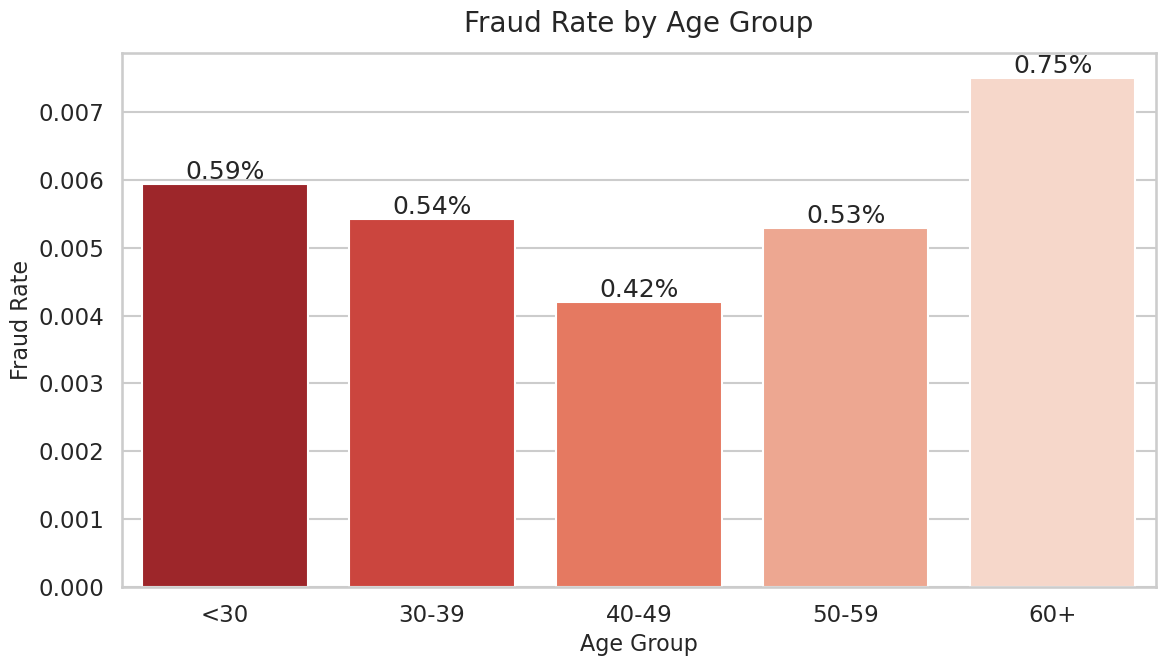

In [14]:
age_band_spark = (
    cc_df.withColumn(
        "age_band",
        F.when(F.col("age") < 30, "<30")
         .when(F.col("age") < 40, "30-39")
         .when(F.col("age") < 50, "40-49")
         .when(F.col("age") < 60, "50-59")
         .otherwise("60+")
    )
)

age_summary_pd = (
    age_band_spark.groupBy("age_band")
    .agg(
        F.count("*").alias("txn_count"),
        F.sum("is_fraud").alias("fraud_count")
    )
    .withColumn("fraud_rate", F.col("fraud_count") / F.col("txn_count"))
    .toPandas()
)

age_order = ["<30", "30-39", "40-49", "50-59", "60+"]

age_summary_pd["age_band"] = pd.Categorical(
    age_summary_pd["age_band"],
    categories=age_order,
    ordered=True
)

age_summary_pd = age_summary_pd.sort_values("age_band").reset_index(drop=True)

plt.figure()

sns.barplot(
    data=age_summary_pd,
    x="age_band",
    y="fraud_rate",
    hue="age_band",
    palette=sns.color_palette("Reds_r", n_colors=len(age_summary_pd)),
    legend=False
)

for i, row in age_summary_pd.iterrows():
    plt.text(
        i,
        row["fraud_rate"],
        f"{row['fraud_rate']*100:.2f}%",
        ha="center",
        va="bottom"
    )

plt.title("Fraud Rate by Age Group", pad=15)
plt.xlabel("Age Group")
plt.ylabel("Fraud Rate")

plt.tight_layout()
plt.show()

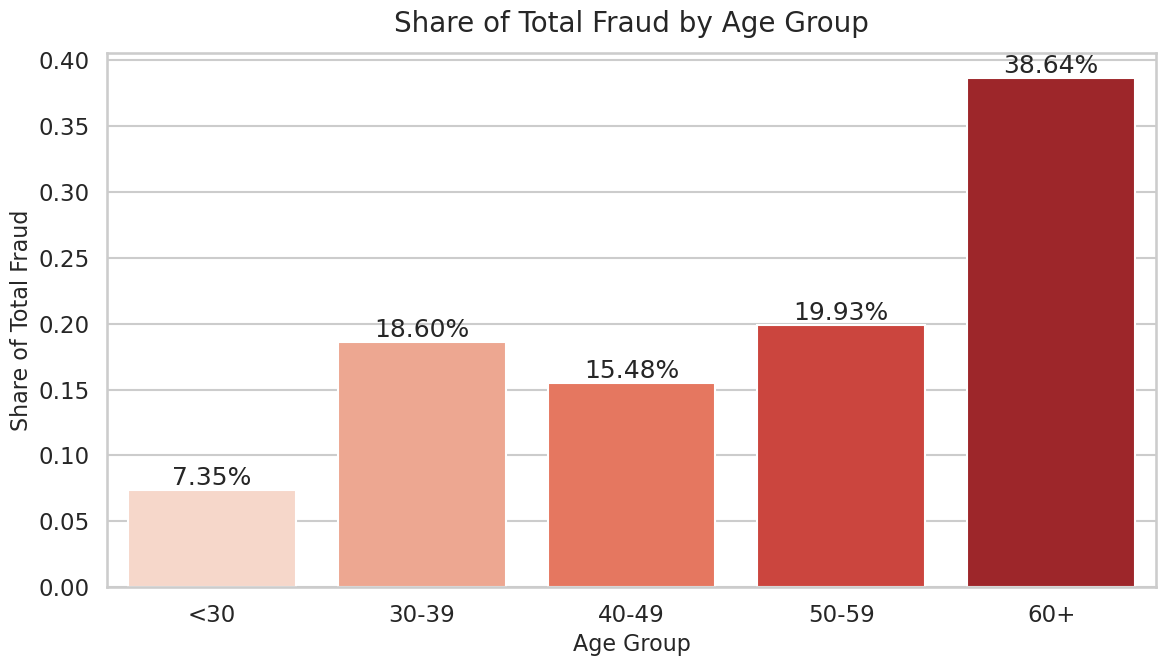

In [15]:
age_order = ["<30", "30-39", "40-49", "50-59", "60+"]

age_summary_pd["age_band"] = pd.Categorical(
    age_summary_pd["age_band"],
    categories=age_order,
    ordered=True
)

age_summary_pd = age_summary_pd.sort_values("age_band").reset_index(drop=True)

age_summary_pd["fraud_share"] = (
    age_summary_pd["fraud_count"] / age_summary_pd["fraud_count"].sum()
)

plt.figure()

sns.barplot(
    data=age_summary_pd,
    x="age_band",
    y="fraud_share",
    hue="age_band",
    palette=sns.color_palette("Reds", n_colors=len(age_summary_pd)),
    legend=False
)

for i, row in age_summary_pd.iterrows():
    plt.text(
        i,
        row["fraud_share"],
        f"{row['fraud_share']*100:.2f}%",
        ha="center",
        va="bottom"
    )

plt.title("Share of Total Fraud by Age Group", pad=15)
plt.xlabel("Age Group")
plt.ylabel("Share of Total Fraud")

plt.tight_layout()
plt.show()

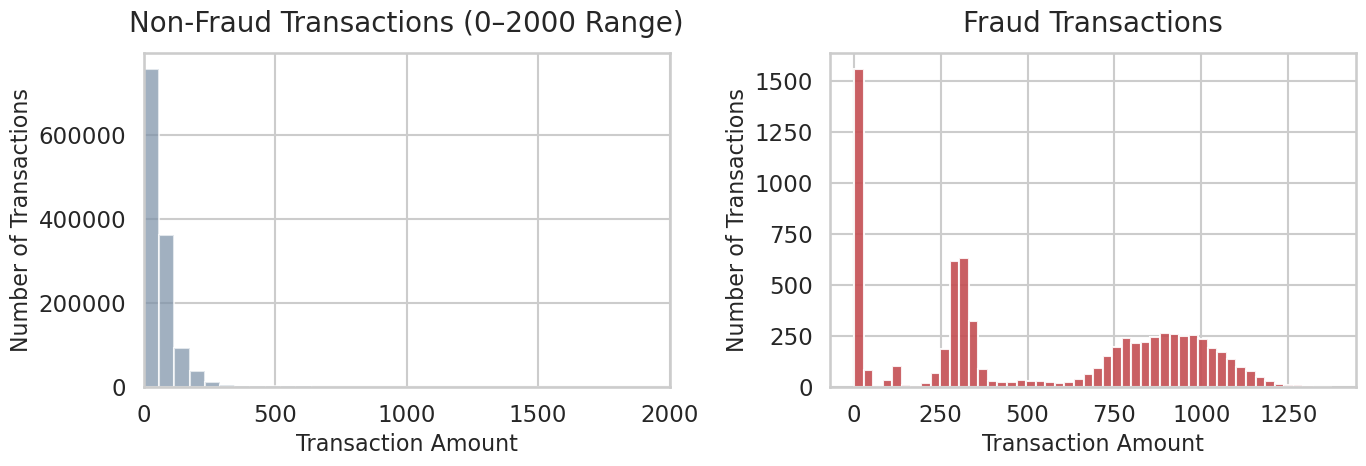

In [16]:
amt_pd = cc_df.select("amt", "is_fraud").toPandas()

nonfraud_amt = amt_pd[amt_pd["is_fraud"] == 0]["amt"]
fraud_amt = amt_pd[amt_pd["is_fraud"] == 1]["amt"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Non-Fraud
axes[0].hist(
    nonfraud_amt,
    bins=500,
    color="#7a8fa6",
    alpha=0.7
)
axes[0].set_title("Non-Fraud Transactions (0–2000 Range)", pad=15)
axes[0].set_xlabel("Transaction Amount")
axes[0].set_ylabel("Number of Transactions")
axes[0].set_xlim(0, 2000)

# Fraud
axes[1].hist(
    fraud_amt,
    bins=50,
    color="#c44e52",
    alpha=0.9
)
axes[1].set_title("Fraud Transactions", pad=15)
axes[1].set_xlabel("Transaction Amount")
axes[1].set_ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

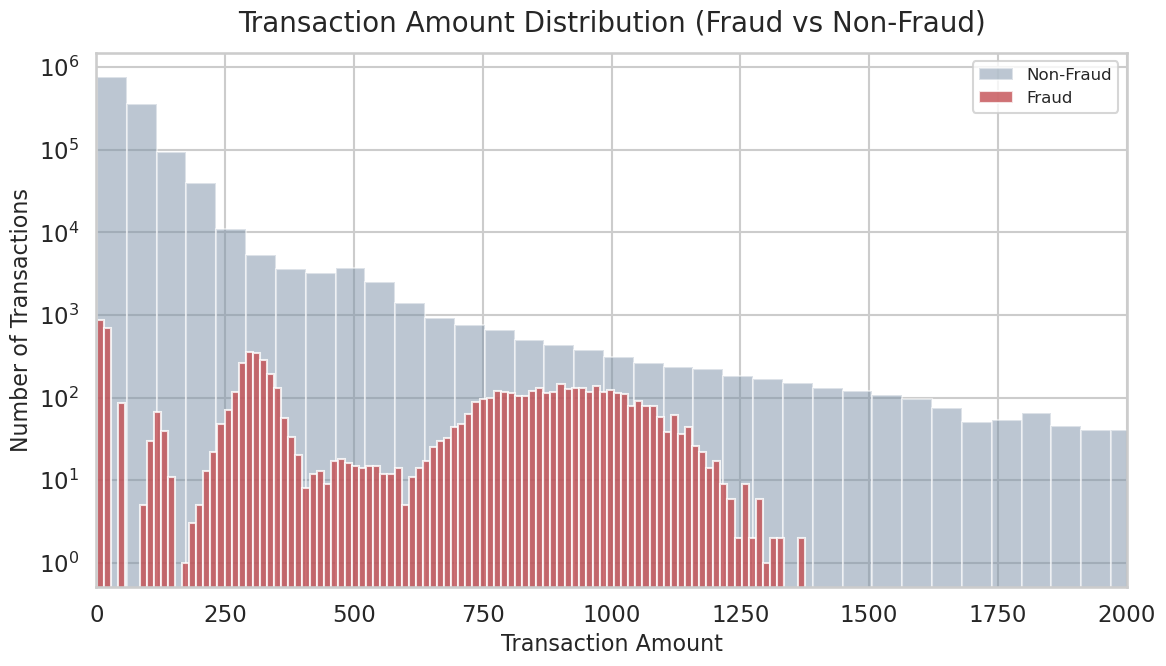

In [17]:
amt_pd = cc_df.select("amt", "is_fraud").toPandas()

fig, ax = plt.subplots()

# Non-Fraud (background)
ax.hist(
    amt_pd[amt_pd["is_fraud"] == 0]["amt"],
    bins=500,
    color="#7a8fa6",
    alpha=0.5,
    label="Non-Fraud"
)

# Fraud (overlay)
ax.hist(
    amt_pd[amt_pd["is_fraud"] == 1]["amt"],
    bins=100,
    color="#c44e52",
    alpha=0.8,
    label="Fraud"
)

ax.set_title("Transaction Amount Distribution (Fraud vs Non-Fraud)", pad=15)
ax.set_xlabel("Transaction Amount")
ax.set_ylabel("Number of Transactions")
ax.set_xlim(0, 2000)
ax.set_yscale("log")
ax.legend()

plt.tight_layout()
plt.show()

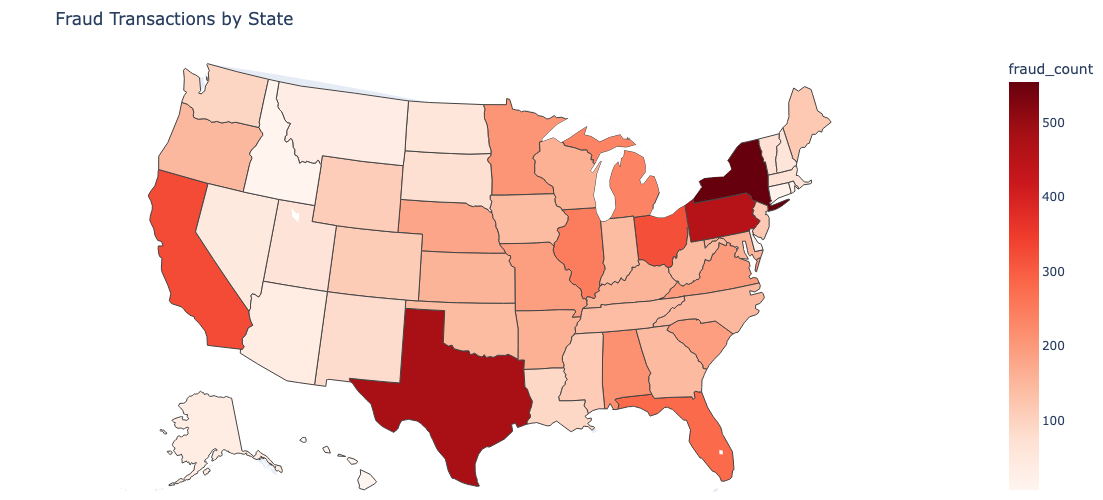

In [18]:
# Aggregate fraud counts by state
state_summary_pd = (
    cc_df.groupBy("state")
    .agg(F.sum("is_fraud").alias("fraud_count"))
    .orderBy(F.desc("fraud_count"))
    .toPandas()
)

fig = px.choropleth(
    state_summary_pd,
    locations="state",
    locationmode="USA-states",
    color="fraud_count",
    scope="usa",
    title="Fraud Transactions by State",
    color_continuous_scale="Reds"
)

fig.update_layout(
    width=900,
    height=500,
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()

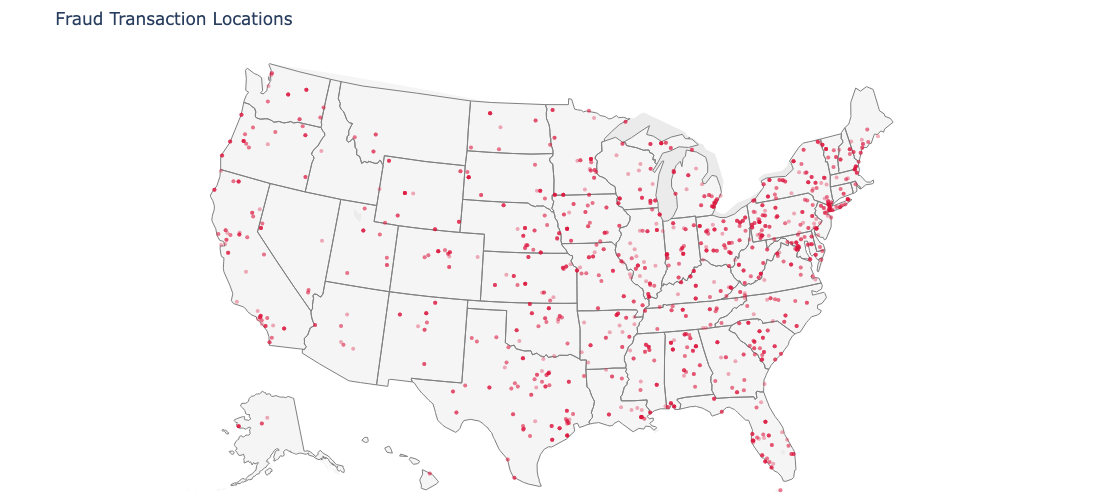

In [19]:
fraud_points_pd = (
    cc_df.filter(F.col("is_fraud") == 1)
         .select("lat", "long", "amt", "category", "state")
         .sample(False, 0.25, seed=5420)   # adjust if you want more/less points
         .toPandas()
)

fig = px.scatter_geo(
    fraud_points_pd,
    lat="lat",
    lon="long",
    scope="usa",
    hover_name="state",
    hover_data={
        "lat": True,
        "long": True,
        "amt": True,
        "category": True
    },
    title="Fraud Transaction Locations"
)

fig.update_traces(
    marker=dict(
        size=4,
        color="crimson",
        opacity=0.35
    )
)

fig.update_geos(
    showcountries=False,
    showsubunits=True,
    subunitcolor="gray",
    showland=True,
    landcolor="rgb(245,245,245)",
    showlakes=True,
    lakecolor="rgb(235,235,235)",
    bgcolor="white"
)

fig.update_layout(
    width=900,
    height=500,
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()

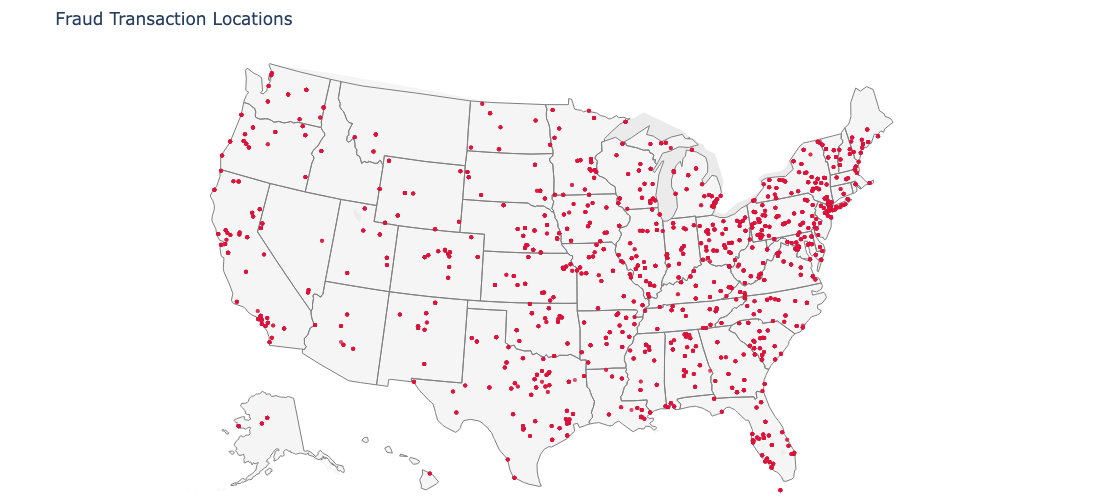

In [20]:
fraud_points_pd = (
    cc_df.filter(F.col("is_fraud") == 1)
         .select("lat", "long", "amt", "category", "state")
         .toPandas()
)

fig = px.scatter_geo(
    fraud_points_pd,
    lat="lat",
    lon="long",
    scope="usa",
    hover_name="state",
    hover_data={
        "amt": True,
        "category": True
    },
    title="Fraud Transaction Locations"
)

fig.update_traces(
    marker=dict(
        size=4,
        color="crimson",
        opacity=0.5
    )
)

fig.update_geos(
    showsubunits=True,
    subunitcolor="gray",
    showland=True,
    landcolor="rgb(245,245,245)",
    showlakes=True,
    lakecolor="rgb(235,235,235)"
)

fig.update_layout(
    width=900,
    height=500,
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()

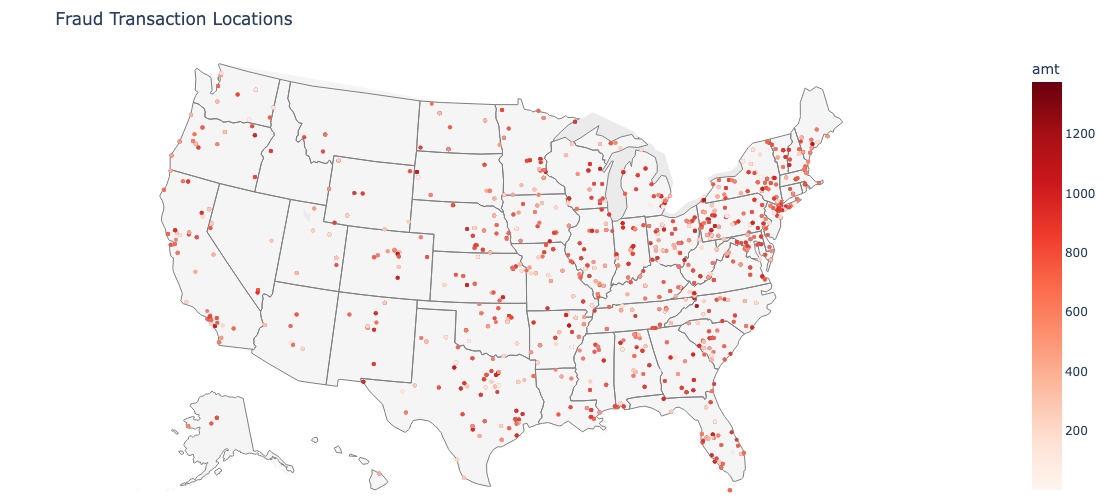

In [21]:
fraud_points_pd = (
    cc_df.filter(F.col("is_fraud") == 1)
         .select("lat", "long", "amt", "category", "state")
         .toPandas()
)

fig = px.scatter_geo(
    fraud_points_pd,
    lat="lat",
    lon="long",
    scope="usa",
    color="amt",
    color_continuous_scale="Reds",
    hover_name="state",
    hover_data={
        "amt": True,
        "category": True
    },
    title="Fraud Transaction Locations"
)

fig.update_traces(
    marker=dict(
        size=4,
        opacity=0.5
    )
)

fig.update_geos(
    showsubunits=True,
    subunitcolor="gray",
    showland=True,
    landcolor="rgb(245,245,245)",
    showlakes=True,
    lakecolor="rgb(235,235,235)"
)

fig.update_layout(
    width=900,
    height=500,
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()

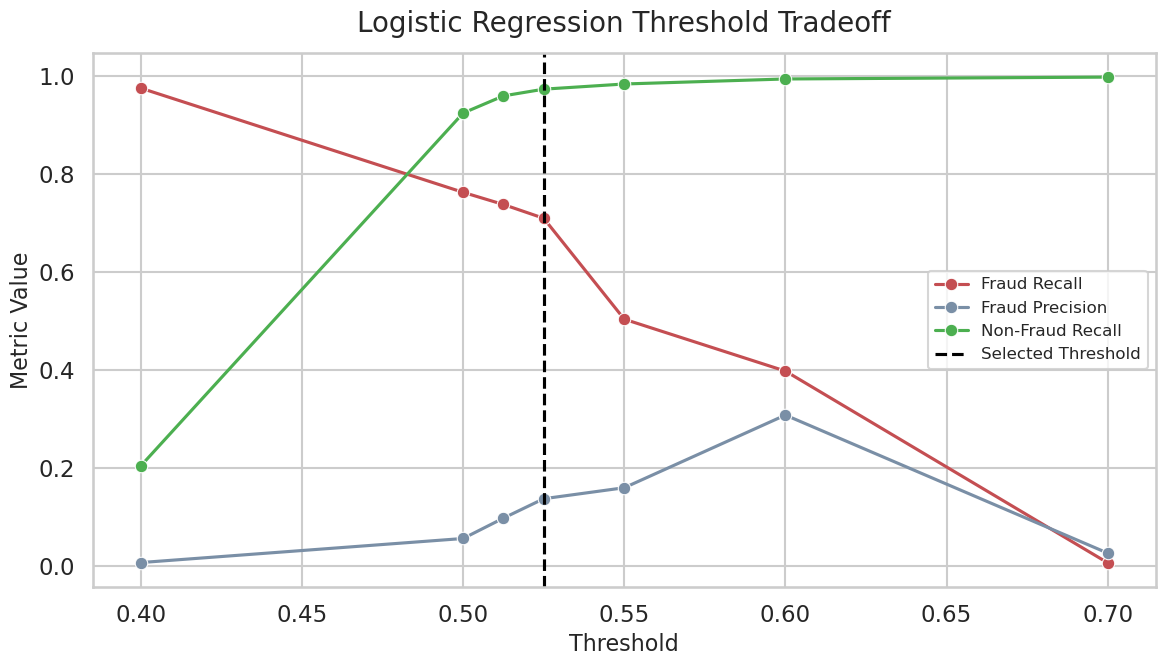

In [22]:
fig, ax = plt.subplots()

sns.lineplot(
    data=lr_threshold_pd,
    x="threshold",
    y="fraud_recall",
    marker="o",
    color="#c44e52",
    label="Fraud Recall",
    ax=ax
)

sns.lineplot(
    data=lr_threshold_pd,
    x="threshold",
    y="fraud_precision",
    marker="o",
    color="#7a8fa6",
    label="Fraud Precision",
    ax=ax
)

sns.lineplot(
    data=lr_threshold_pd,
    x="threshold",
    y="nonfraud_recall",
    marker="o",
    color="#4CAF50",
    label="Non-Fraud Recall",
    ax=ax
)

ax.axvline(0.525, linestyle="--", color="black", label="Selected Threshold")

ax.set_title("Logistic Regression Threshold Tradeoff", pad=15)
ax.set_xlabel("Threshold")
ax.set_ylabel("Metric Value")
ax.legend()

plt.tight_layout()
plt.show()

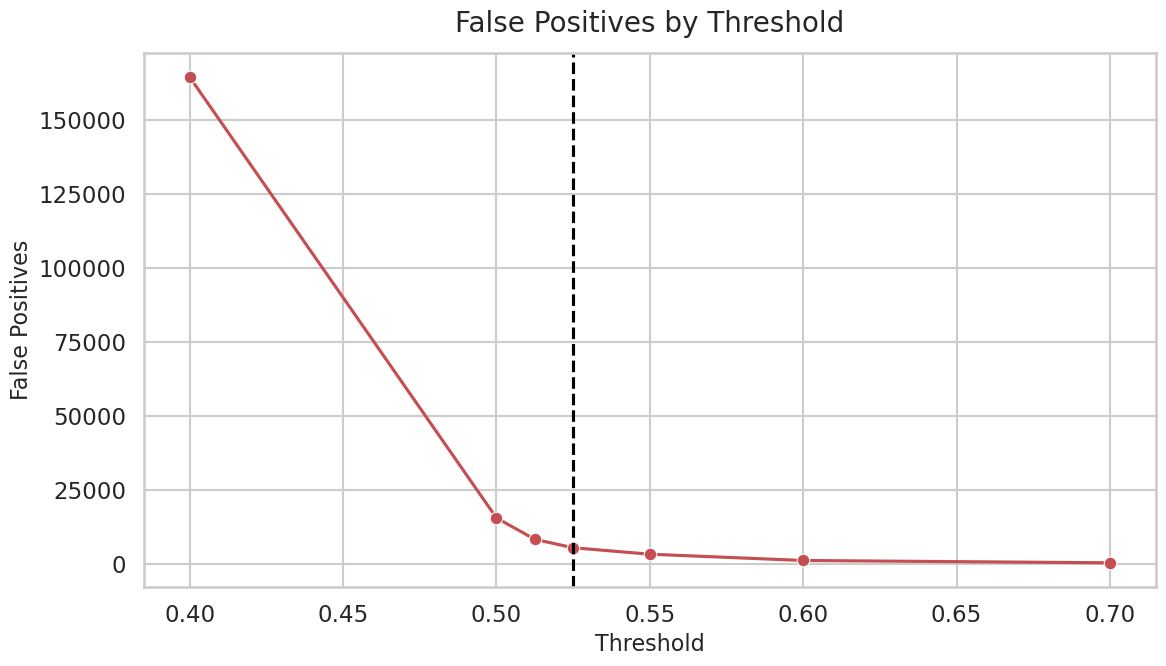

In [23]:
fig, ax = plt.subplots()

sns.lineplot(
    data=lr_threshold_pd,
    x="threshold",
    y="fp",
    marker="o",
    color="#c44e52",
    ax=ax
)

ax.axvline(0.525, linestyle="--", color="black")

ax.set_title("False Positives by Threshold", pad=15)
ax.set_xlabel("Threshold")
ax.set_ylabel("False Positives")

plt.tight_layout()
plt.show()

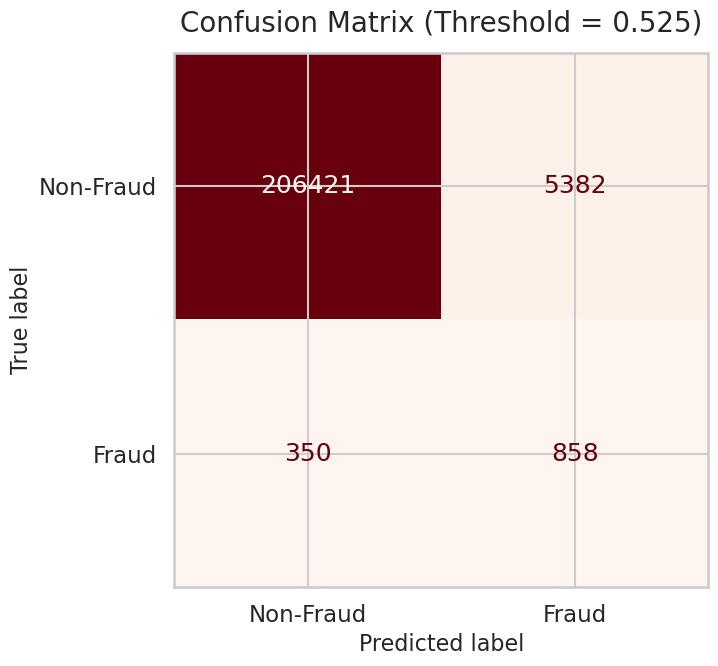

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

# Pull values from your selected row manually if needed
tn = 206421
fp = 5382
fn = 350
tp = 858

cm = np.array([[tn, fp],
               [fn, tp]])

fig, ax = plt.subplots()

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Fraud", "Fraud"])
disp.plot(ax=ax, cmap="Reds", colorbar=False)

ax.set_title("Confusion Matrix (Threshold = 0.525)", pad=15)

plt.tight_layout()
plt.show()

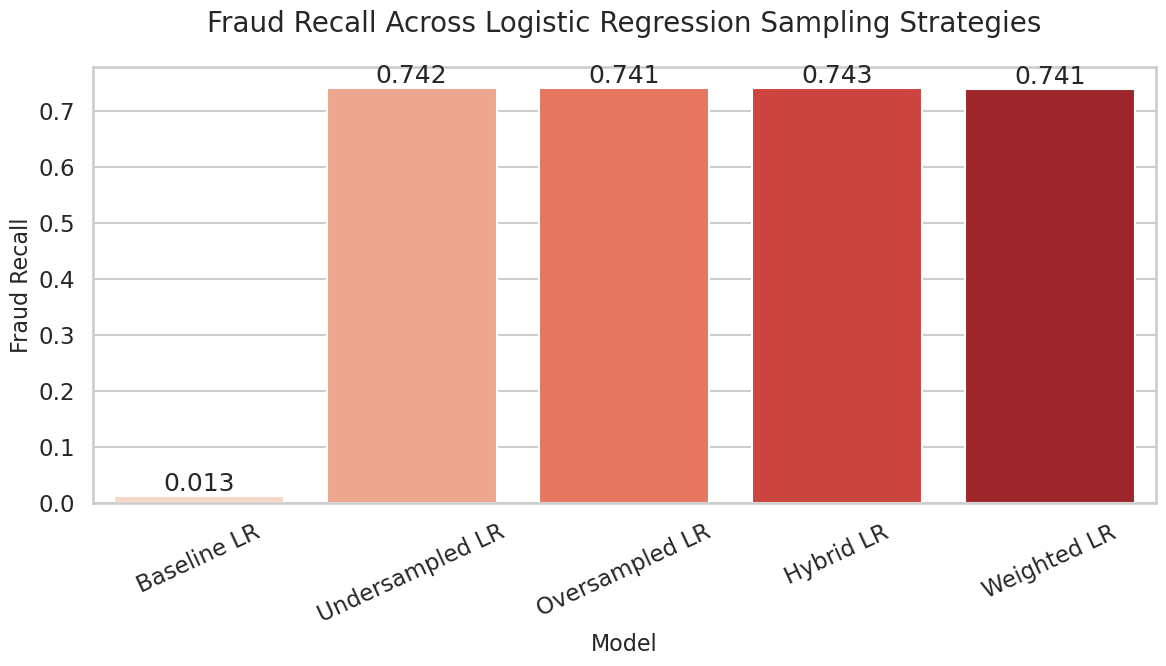

In [25]:
imbalance_lr_pd = pd.DataFrame({
    "model": [
        "Baseline LR",
        "Undersampled LR",
        "Oversampled LR",
        "Hybrid LR",
        "Weighted LR"
    ],
    "fraud_recall": [0.0130, 0.7420, 0.7414, 0.7427, 0.7407]
})

fig, ax = plt.subplots()

sns.barplot(
    data=imbalance_lr_pd,
    x="model",
    y="fraud_recall",
    hue="model",
    palette="Reds",
    legend=False,
    ax=ax
)

ax.set_title("Fraud Recall Across Logistic Regression Sampling Strategies", pad=25)
ax.set_xlabel("Model")
ax.set_ylabel("Fraud Recall")
ax.tick_params(axis="x", rotation=25)

for i, row in imbalance_lr_pd.iterrows():
    ax.text(i, row["fraud_recall"], f"{row['fraud_recall']:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

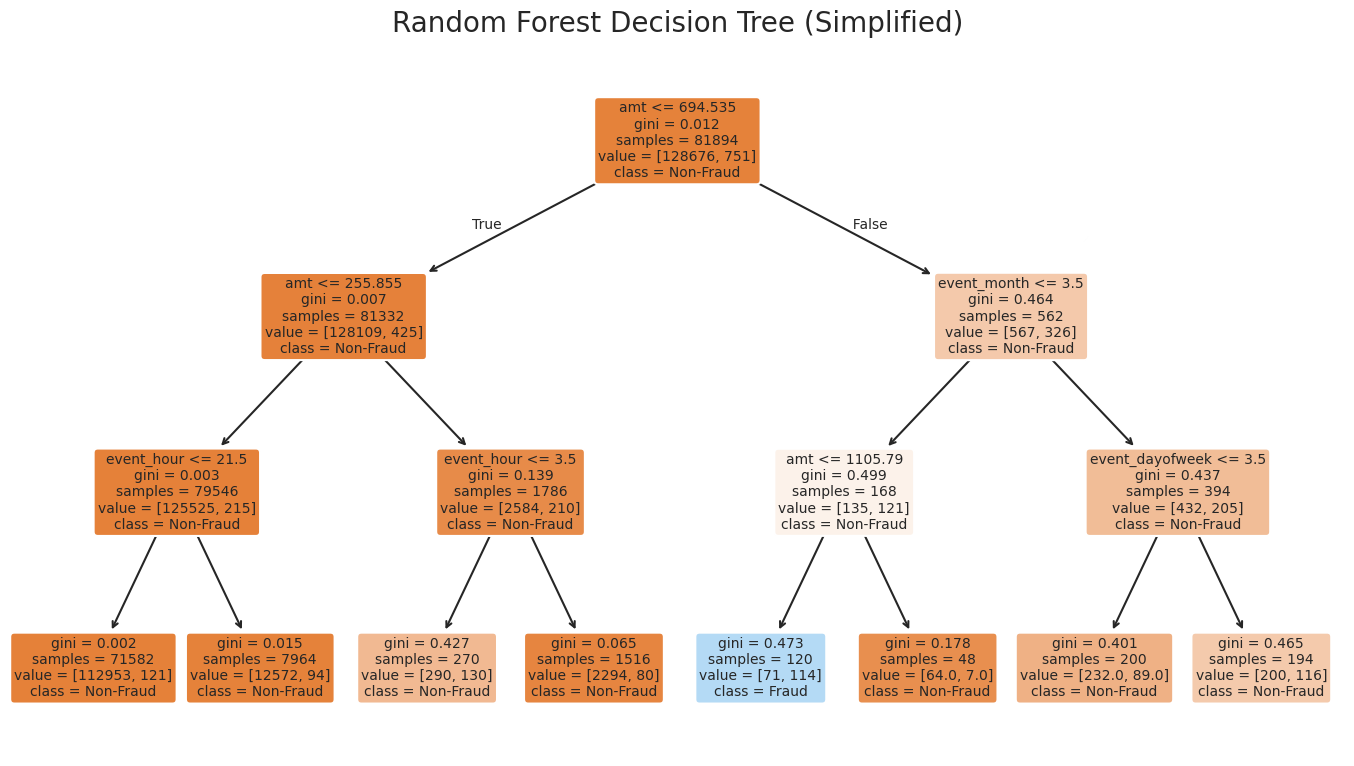

In [26]:
# Small sample + simple features for readability
rf_vis_df = cc_df.select(
        "is_fraud",
        "amt",
        "age",
        "event_hour",
        "event_month",
        "event_dayofweek").sample(False, 0.1, seed=5420).toPandas()

X = rf_vis_df.drop(columns=["is_fraud"])
y = rf_vis_df["is_fraud"]

rf_vis = RandomForestClassifier( # recreate a small tree
    n_estimators=1,
    max_depth=3, # Shallow depth so not overwhelming
    random_state=5420
)

rf_vis.fit(X, y)

tree = rf_vis.estimators_[0]

# Plot
fig, ax = plt.subplots(figsize=(14, 8))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["Non-Fraud", "Fraud"],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)

ax.set_title("Random Forest Decision Tree (Simplified)", pad=15)

plt.tight_layout()
plt.show()

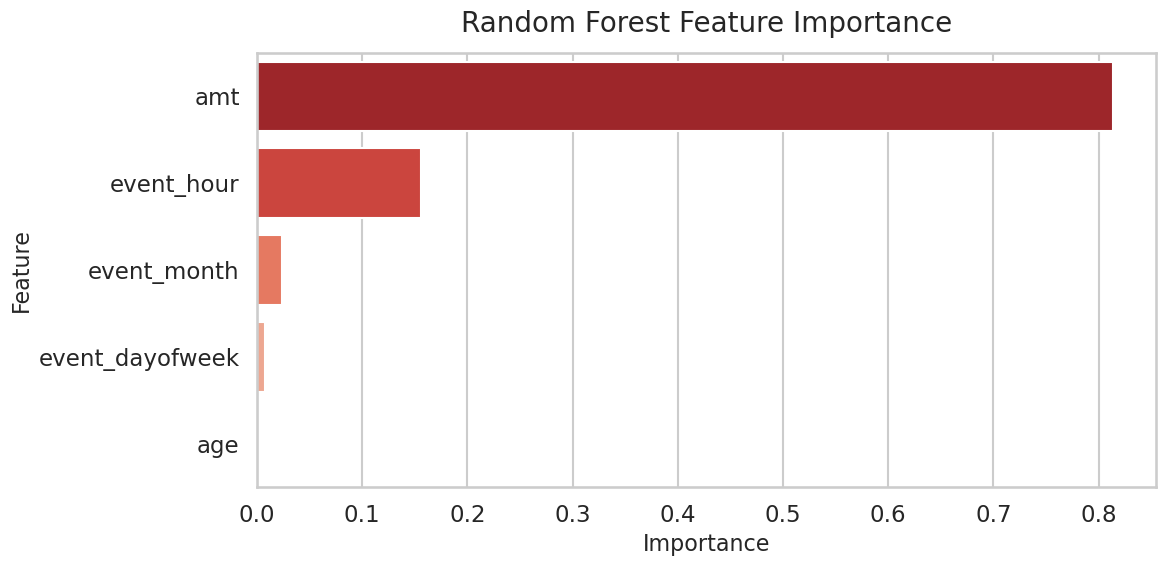

In [27]:
feature_importance_pd = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_vis.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=feature_importance_pd,
    x="importance",
    y="feature",
    hue="feature",
    palette=sns.color_palette("Reds_r", n_colors=len(feature_importance_pd)),
    legend=False,
    ax=ax
)

ax.set_title("Random Forest Feature Importance", pad=15)
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

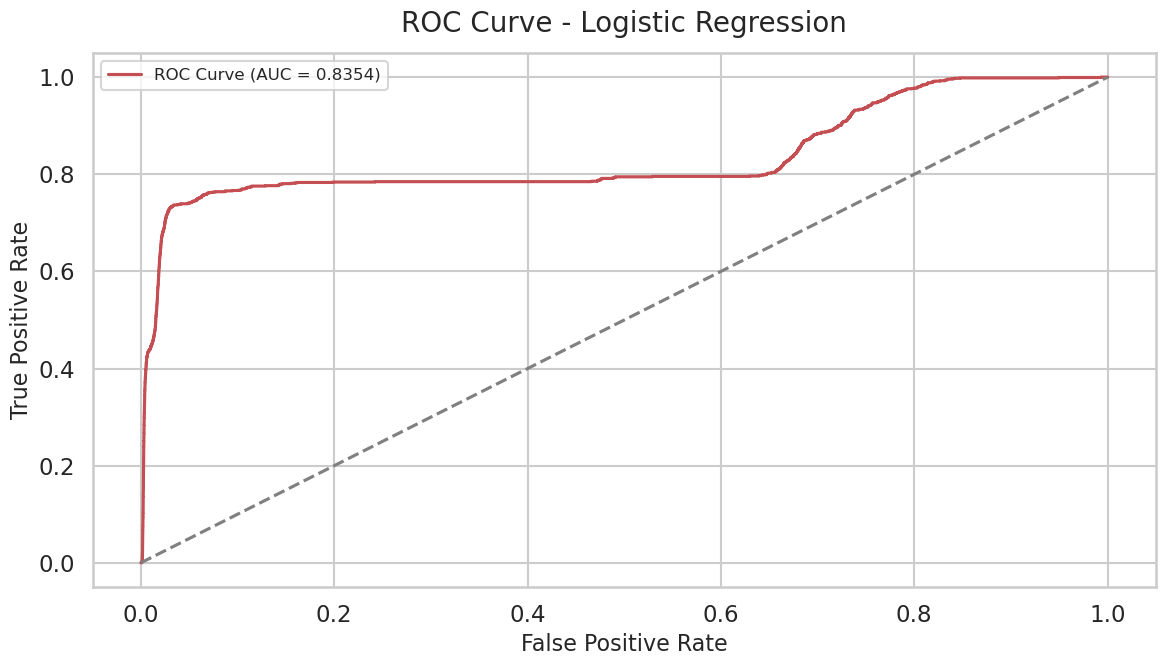

In [28]:
y_true = lr_scored_pd["is_fraud"]
y_score = lr_scored_pd["fraud_prob"]

fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots()

ax.plot(fpr, tpr, color="#c44e52", label=f"ROC Curve (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")

ax.set_title("ROC Curve - Logistic Regression", pad=15)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()

plt.tight_layout()
plt.show()

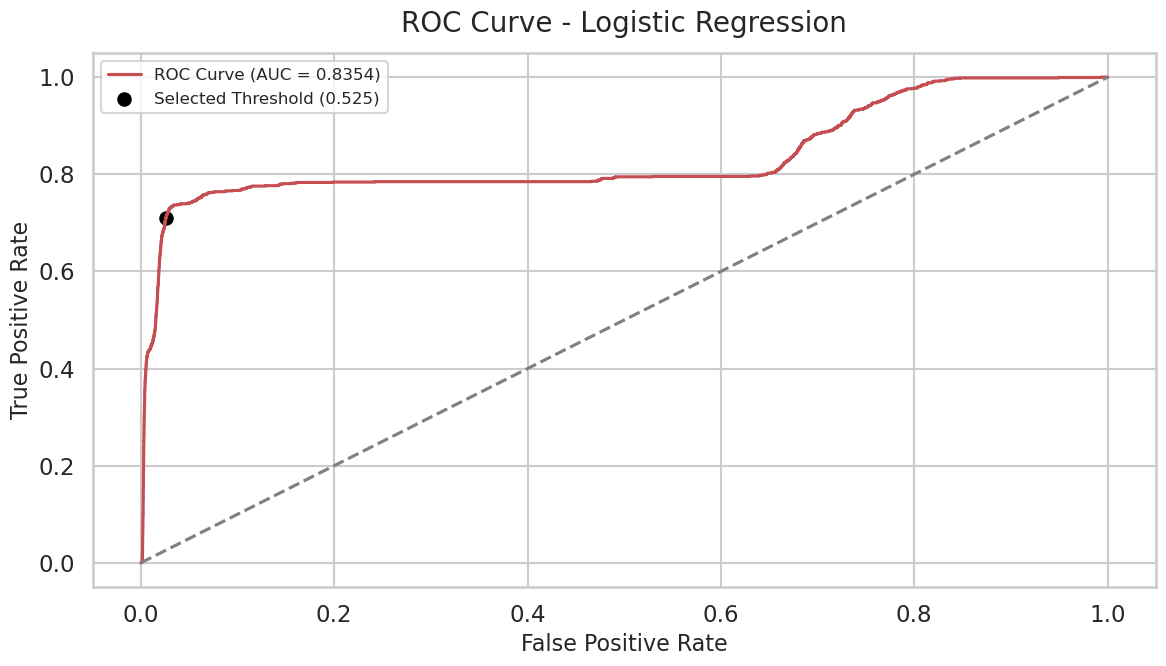

In [29]:
fig, ax = plt.subplots()

ax.plot(fpr, tpr, color="#c44e52", label=f"ROC Curve (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")

# Mark your selected threshold
target_threshold = 0.525
idx = np.argmin(np.abs(thresholds - target_threshold))

ax.scatter(
    fpr[idx],
    tpr[idx],
    color="black",
    s=80,
    label="Selected Threshold (0.525)"
)

ax.set_title("ROC Curve - Logistic Regression", pad=15)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.legend()

plt.tight_layout()
plt.show()

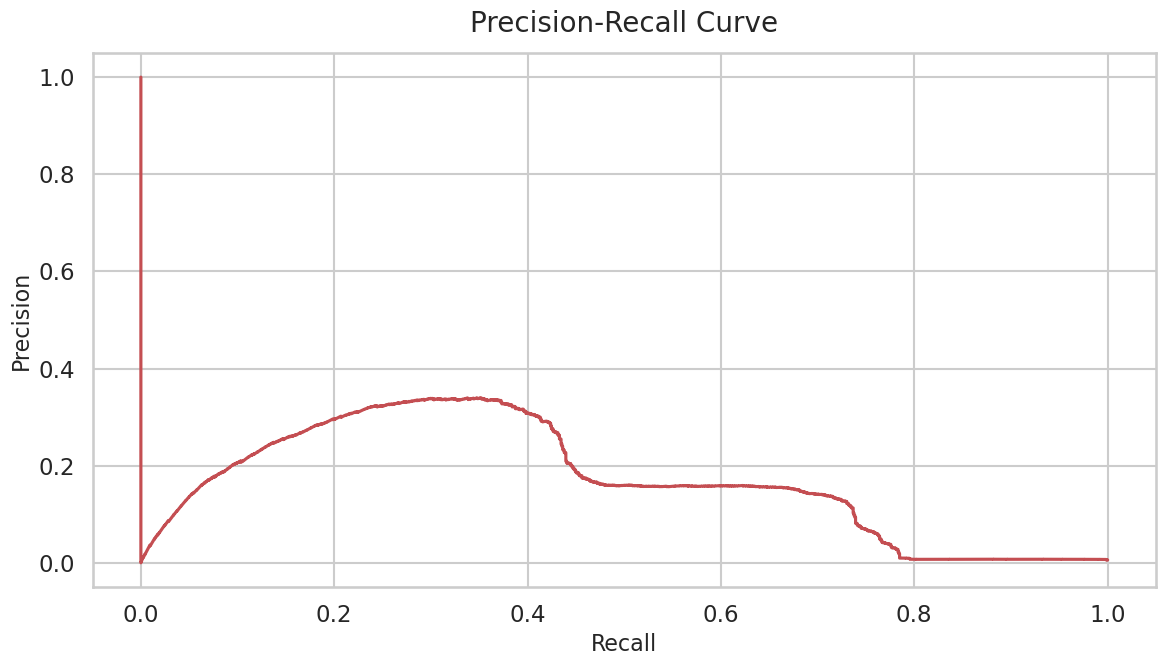

In [30]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, y_score)

fig, ax = plt.subplots()

ax.plot(recall, precision, color="#c44e52")

ax.set_title("Precision-Recall Curve", pad=15)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

plt.tight_layout()
plt.show()

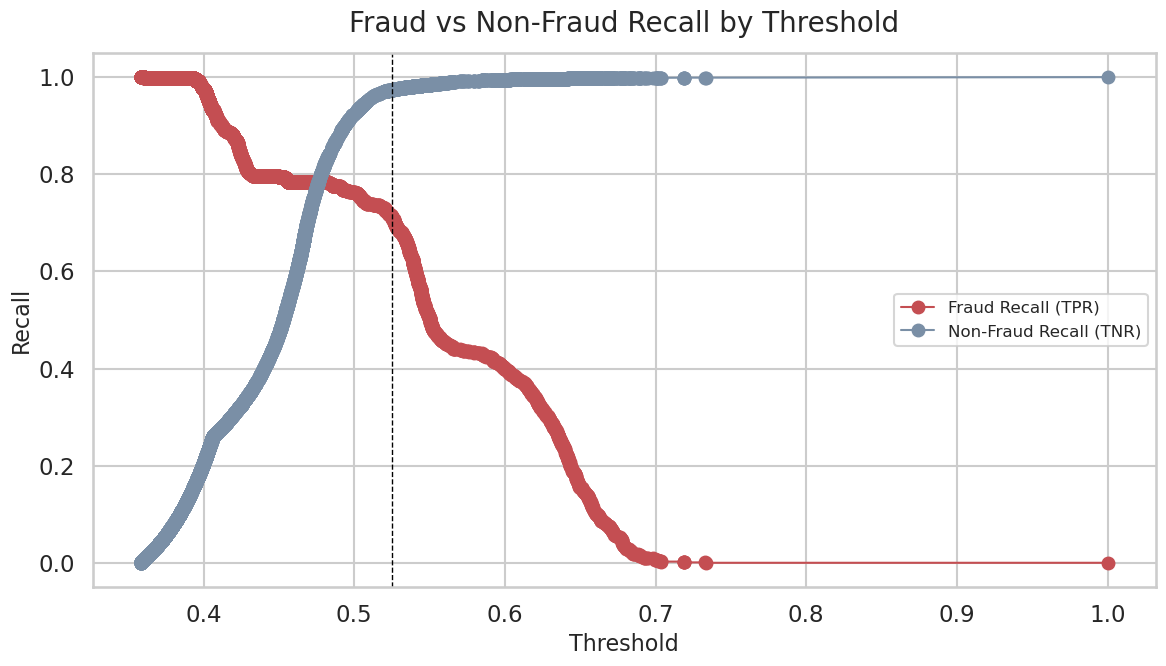

In [31]:
fig, ax = plt.subplots()

ax.plot(
    thresholds,
    tpr,
    marker="o",
    linewidth=1.5,
    color="#c44e52",
    label="Fraud Recall (TPR)"
)

ax.plot(
    thresholds,
    1 - fpr,
    marker="o",
    linewidth=1.5,
    color="#7a8fa6",
    label="Non-Fraud Recall (TNR)"
)

ax.axvline(0.525, linestyle="--", color="black", linewidth=1)

ax.set_title("Fraud vs Non-Fraud Recall by Threshold", pad=15)
ax.set_xlabel("Threshold")
ax.set_ylabel("Recall")

ax.legend()

plt.tight_layout()
plt.show()